# Visualize and Inpsect Query Niche

Enter a **center cell name**, **slice name**, and **niche dimension**, then run the cells in order. The example selects a large niche. Target cell counts come from `experiment/manifests/query_niche_dimensions.json`. A target is a minimum: the saved neighborhood can contain more cells. Current CSVs contain only niches that reached the target and are read from the selected dimension directory. Older CSVs are filtered by `target_niche_size` and `target_size_reached` when those columns exist.

The figure highlights the exact `niche_cell_names` saved in the metrics CSV, with a star for the center. Outputs include basic niche metrics with nonzero parcellation fractions as an ID-to-fraction JSON map, source- and target-slice composition similarity counts and percentages, center coordinates, a member-cell table, a parcellation composition table, and a PNG.

Run locally using the repository’s `.venv` kernel and set `PROJECT_ROOT` to your local checkout. Outputs are saved in `OUTPUT_DIR`. CSVs are streamed; expression matrices are not loaded. Cell IDs are always treated as strings.

##### Notes to select a desired query niche:
- Source prevalence: The query pattern should occur sufficiently often in the source slice, rather than being a one-off accidental neighborhood.
- Target matchability: Before using a niche for transfer evaluation, check whether comparable niches actually exist in the target slice(s).
- Benchmark diversity
- Low redundancy
- Spatial validity: The niche should correspond to a real, spatially coherent neighborhood rather than an arbitrary mixture of cells.

In [3]:
# Local inputs. Set PROJECT_ROOT to your repository checkout.
PROJECT_ROOT = "/home/sheryl/niche_query/NicheQueryBenchmark"
CENTER_CELL_NAME = "1019171910101420741"
SLICE_NAME = "C57BL6J-638850.28"
NICHE_DIMENSION = "large"
# Relative paths are resolved against PROJECT_ROOT.
METRICS_DIR = f"experiment/query_niche_metrics/{NICHE_DIMENSION}"
DATA_DIR = "data/20260601_225717"
OUTPUT_DIR = f"experiment/query_niche_metrics/selected_query_niches/{SLICE_NAME}_{CENTER_CELL_NAME}/{NICHE_DIMENSION}"
SPATIAL_KEY = "spatial"
INVERT_Y_AXIS = False


In [4]:
import csv
import json
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Some niche membership fields exceed Python's default CSV field-size limit.
csv.field_size_limit(100_000_000)
root = Path(PROJECT_ROOT).expanduser()
with (root / "experiment/manifests/query_niche_dimensions.json").open(encoding="utf-8") as handle:
    QUERY_NICHE_DIMENSIONS = json.load(handle)["niche_size"]
TARGET_SIZE = QUERY_NICHE_DIMENSIONS[NICHE_DIMENSION]
def resolve_path(value):
    path = Path(value).expanduser()
    return path if path.is_absolute() else root / path

def eligible_niche(record, target_size):
    # Current exports are already filtered; retain support for older CSVs.
    if 'target_niche_size' in record and int(record['target_niche_size']) != target_size:
        return False
    if ('target_size_reached' in record
            and record['target_size_reached'].strip().lower() != 'true'):
        return False
    return int(record['niche_cell_count']) >= target_size

def find_niche(csv_path, center_name, target_size):
    if not csv_path.is_file():
        raise FileNotFoundError(f'Metrics CSV not found: {csv_path}')
    with csv_path.open(newline='', encoding='utf-8') as handle:
        reader = csv.DictReader(handle)
        required = {'center_cell_name', 'niche_cell_names', 'niche_cell_count',
                    'parcellation_fractions'}
        missing = required - set(reader.fieldnames or [])
        if missing:
            raise ValueError(f'Missing CSV columns: {sorted(missing)}')
        for record in reader:
            if record['center_cell_name'] == center_name and eligible_niche(record, target_size):
                return record
    raise ValueError(f'No eligible niche for center {center_name!r} and target '
                     f'{target_size} in {csv_path.name}.')

CENTER_CELL_NAME = str(CENTER_CELL_NAME).strip()
SLICE_NAME = SLICE_NAME.strip()
if not CENTER_CELL_NAME or not SLICE_NAME or Path(SLICE_NAME).name != SLICE_NAME:
    raise ValueError('Enter a center cell name and a slice filename stem without directories.')
if isinstance(TARGET_SIZE, bool) or not isinstance(TARGET_SIZE, int) or TARGET_SIZE < 1:
    raise ValueError('TARGET_SIZE must be a positive integer.')
metrics_path = resolve_path(METRICS_DIR) / f'{SLICE_NAME}.csv'
h5ad_path = resolve_path(DATA_DIR) / f'{SLICE_NAME}.h5ad'
row = find_niche(metrics_path, CENTER_CELL_NAME, TARGET_SIZE)
member_names = json.loads(row['niche_cell_names'])
if not isinstance(member_names, list) or not all(isinstance(x, str) for x in member_names):
    raise ValueError('niche_cell_names must be a JSON array of string cell IDs.')
if len(set(member_names)) != len(member_names):
    raise ValueError('The saved niche contains duplicate cell IDs.')
if len(member_names) != int(row['niche_cell_count']) or len(member_names) < TARGET_SIZE:
    raise ValueError('Saved membership disagrees with niche count or target size.')
if CENTER_CELL_NAME not in member_names:
    raise ValueError('The saved niche does not contain the center cell.')

if not h5ad_path.is_file():
    raise FileNotFoundError(f'Slice H5AD not found: {h5ad_path}')
adata = ad.read_h5ad(h5ad_path, backed='r')
try:
    if SPATIAL_KEY not in adata.obsm:
        raise KeyError(f'{SPATIAL_KEY!r} not found. Available keys: {list(adata.obsm)}')
    coords = np.asarray(adata.obsm[SPATIAL_KEY], dtype=float).copy()
    cell_names = pd.Index(adata.obs_names.astype(str))
    obs = adata.obs.copy()
finally:
    adata.file.close()
if not cell_names.is_unique:
    raise ValueError('Slice cell IDs are not unique.')
if coords.ndim != 2 or coords.shape[0] != len(cell_names) or coords.shape[1] < 2:
    raise ValueError('Coordinates must have shape (number of cells, at least 2).')
if not np.isfinite(coords).all():
    raise ValueError('Slice coordinates contain non-finite values.')
member_indices = cell_names.get_indexer(member_names)
if (member_indices < 0).any():
    missing = [name for name, idx in zip(member_names, member_indices) if idx < 0]
    raise ValueError(f'{len(missing)} niche cells missing from slice; examples: {missing[:5]}')
center_index = cell_names.get_loc(CENTER_CELL_NAME)
center_coords = coords[center_index]
coordinate_columns = ['spatial_x', 'spatial_y'] + [f'spatial_dim_{i}' for i in range(2, coords.shape[1])]
print(f'Loaded {len(member_names)} niche cells in a slice of {len(cell_names):,} cells.')
print('Center coordinates:', dict(zip(coordinate_columns, center_coords)))
print('Coordinates use the original H5AD units; the plot uses the first two dimensions.')


Loaded 349 niche cells in a slice of 79,139 cells.
Center coordinates: {'spatial_x': np.float64(5.318969936953236), 'spatial_y': np.float64(7.415672952120987)}
Coordinates use the original H5AD units; the plot uses the first two dimensions.


## Source-slice composition
Two source-slice niches have similar composition if every parcellation's fraction differs by **strictly less than 0.05 (5 percentage points)**. Fractions are aligned by parcellation ID; missing IDs are treated as zero.

Prevalence is the number of similar niches divided by all eligible exported niches in the source slice and selected dimension, expressed as a percentage. Counts include the selected niche itself and overlapping neighborhoods.


In [5]:
def validated_parcellation_ids(values):
    if (not isinstance(values, list) or not values
            or any(isinstance(value, bool) or not isinstance(value, int) for value in values)
            or len(values) != len(set(values))):
        raise ValueError('Parcellation IDs must be a nonempty list of unique integers.')
    return values

def read_composition(record, shared_ids):
    # Prefer per-row IDs for legacy CSVs, which may use a sparse/local order.
    ids = (validated_parcellation_ids(json.loads(record['parcellation_ids']))
           if 'parcellation_ids' in record else shared_ids)
    if ids is None:
        raise ValueError('Missing parcellation_ids.json and per-row parcellation_ids.')
    fractions = np.asarray(json.loads(record['parcellation_fractions']), dtype=float)
    if (fractions.ndim != 1 or len(fractions) != len(ids)
            or not np.isfinite(fractions).all() or (fractions < 0).any()
            or not np.isclose(fractions.sum(), 1.0, rtol=1e-6, atol=1e-8)):
        raise ValueError(f"Invalid composition vector for center {record['center_cell_name']!r}.")
    # Remove only roundoff in an already validated probability distribution.
    fractions = fractions / fractions.sum()
    return dict(zip(ids, fractions))

# Fractions use a 0–1 scale: 0.05 means five percentage points.
SOURCE_COMPOSITION_FRACTION_THRESHOLD = 0.05
TARGET_COMPOSITION_FRACTION_THRESHOLD = 0.25

def similar_composition(query, candidate, threshold):
    ids = query.keys() | candidate.keys()
    differences = np.array([abs(query.get(key, 0.0) - candidate.get(key, 0.0))
                            for key in ids])
    # Exclude equality at the strict threshold despite floating-point roundoff.
    at_threshold = np.isclose(differences, threshold,
                              rtol=0.0, atol=1e-12)
    return bool(np.all((differences < threshold) & ~at_threshold))

def load_shared_parcellation_ids(csv_path):
    ids_path = csv_path.parent / 'parcellation_ids.json'
    if ids_path.is_file():
        with ids_path.open(encoding='utf-8') as handle:
            return validated_parcellation_ids(json.load(handle))
    return None

def composition_prevalence(candidate_count, similar_count):
    return {
        'candidate_niche_count': candidate_count,
        'similar_niche_count': similar_count,
        'similar_niche_percent': (100.0 * similar_count / candidate_count
                                  if candidate_count else np.nan),
    }

def source_slice_composition_statistics(csv_path, selected_row, target_size, source_cell_names):
    shared_ids = load_shared_parcellation_ids(csv_path)
    query = read_composition(selected_row, shared_ids)
    source_ids = set(source_cell_names)
    seen = set()
    comparisons = []
    with csv_path.open(newline='', encoding='utf-8') as handle:
        for candidate in csv.DictReader(handle):
            if not eligible_niche(candidate, target_size):
                continue
            center = candidate['center_cell_name']
            if center not in source_ids:
                raise ValueError(f'Candidate center {center!r} is absent from the source slice.')
            if center in seen:
                raise ValueError(f'Duplicate eligible candidate center: {center!r}.')
            seen.add(center)
            comparisons.append({
                'center_cell_name': center,
                'niche_cell_count': int(candidate['niche_cell_count']),
                'is_similar_composition': similar_composition(
                    query, read_composition(candidate, shared_ids),
                    SOURCE_COMPOSITION_FRACTION_THRESHOLD),
                'is_selected_niche': center == selected_row['center_cell_name'],
            })
    if not comparisons or selected_row['center_cell_name'] not in seen:
        raise ValueError('The comparison population must include the selected niche.')
    comparisons_df = pd.DataFrame(comparisons)
    summary = {
        **composition_prevalence(len(comparisons_df),
                                 int(comparisons_df['is_similar_composition'].sum())),
        'composition_fraction_difference_threshold': SOURCE_COMPOSITION_FRACTION_THRESHOLD,
        'composition_similarity_rule': 'absolute difference < 0.05 for every parcellation',
        'composition_includes_selected_niche': True,
        'composition_population': 'eligible exported niches in source slice and dimension',
        'source_slice_cell_count': len(source_ids),
    }
    return query, comparisons_df, summary

query_composition, source_composition_df, source_composition_summary = source_slice_composition_statistics(
    metrics_path, row, TARGET_SIZE, cell_names)
parcellation_ids = list(query_composition)
print(f"Similar source-slice niches: {source_composition_summary['similar_niche_count']:,} / "
      f"{source_composition_summary['candidate_niche_count']:,} "
      f"({source_composition_summary['similar_niche_percent']:.2f}%; includes the selected niche).")
display(pd.DataFrame([{key: source_composition_summary[key] for key in
                      ['candidate_niche_count', 'similar_niche_count', 'similar_niche_percent']}]))



Similar source-slice niches: 280 / 78,615 (0.36%; includes the selected niche).


,candidate_niche_count,similar_niche_count,similar_niche_percent
0,78615,280,0.356166


## Target-slice composition
Compare the selected source niche with every eligible exported niche in each other slice CSV in `METRICS_DIR` (the same niche dimension), excluding the source CSV.

For target slices, niches have similar composition if the absolute difference in every parcellation fraction is **strictly less than 0.25 (25 percentage points)**. Align fractions by parcellation ID, treating missing IDs as zero.

For each target slice, show the number of similar niches and their percentage of all eligible exported niches in that slice. Slices with no eligible niches have a count of zero and an undefined (`NaN`) percentage. Slices without a CSV are not compared.


In [6]:
def composition_by_target_slice(source_csv, query, target_size):
    shared_ids = load_shared_parcellation_ids(source_csv)
    results = []
    target_paths = [path for path in sorted(source_csv.parent.glob('*.csv'))
                    if path.resolve() != source_csv.resolve()]
    for target_path in target_paths:
        seen = set()
        similar_count = 0
        with target_path.open(newline='', encoding='utf-8') as handle:
            reader = csv.DictReader(handle)
            required = {'center_cell_name', 'niche_cell_count', 'parcellation_fractions'}
            missing = required - set(reader.fieldnames or [])
            if missing:
                raise ValueError(f'{target_path.name}: missing CSV columns: {sorted(missing)}')
            for candidate in reader:
                if not eligible_niche(candidate, target_size):
                    continue
                center = candidate['center_cell_name']
                if center in seen:
                    raise ValueError(f'{target_path.name}: duplicate eligible center {center!r}.')
                seen.add(center)
                similar_count += similar_composition(
                    query, read_composition(candidate, shared_ids),
                    TARGET_COMPOSITION_FRACTION_THRESHOLD)
        results.append({
            'target_slice': target_path.stem,
            **composition_prevalence(len(seen), similar_count),
            'composition_fraction_difference_threshold': TARGET_COMPOSITION_FRACTION_THRESHOLD,
            'status': 'ok' if seen else 'no eligible niches',
            'target_metrics_csv': str(target_path),
        })
        print(f'{target_path.stem}: {similar_count:,} similar niches / {len(seen):,} eligible niches.')
    columns = ['target_slice', 'candidate_niche_count', 'similar_niche_count',
               'similar_niche_percent', 'composition_fraction_difference_threshold',
               'status', 'target_metrics_csv']
    return pd.DataFrame(results, columns=columns)

cross_slice_composition_df = composition_by_target_slice(metrics_path, query_composition, TARGET_SIZE)
cross_slice_composition_df.insert(0, 'source_center_cell_name', CENTER_CELL_NAME)
cross_slice_composition_df.insert(0, 'source_slice', SLICE_NAME)
cross_slice_composition_df.insert(2, 'niche_dimension', NICHE_DIMENSION)
slice_composition_table = cross_slice_composition_df[
    ['target_slice', 'candidate_niche_count', 'similar_niche_count', 'similar_niche_percent']].rename(
        columns={'target_slice': 'slice name', 'candidate_niche_count': 'eligible niches',
                 'similar_niche_count': 'similar niches', 'similar_niche_percent': 'similar niches (%)'})
if cross_slice_composition_df.empty:
    print(f'No other slice CSVs found in {metrics_path.parent}.')
else:
    print(f'Selected niche: {CENTER_CELL_NAME} | source slice: {SLICE_NAME} | dimension: {NICHE_DIMENSION}')
    print('Similar composition per target slice (every fraction differs by less than 25 percentage points):')
    with pd.option_context('display.max_rows', None, 'display.max_columns', None,
                           'display.precision', 2):
        display(slice_composition_table)



C57BL6J-638850.29: 675 similar niches / 77,292 eligible niches.
C57BL6J-638850.30: 0 similar niches / 90,787 eligible niches.
C57BL6J-638850.31: 0 similar niches / 91,452 eligible niches.
Zhuang-ABCA-1.096: 0 similar niches / 27,765 eligible niches.
Zhuang-ABCA-1.097: 42 similar niches / 25,432 eligible niches.
Zhuang-ABCA-1.098: 357 similar niches / 26,175 eligible niches.
Zhuang-ABCA-1.099: 1,034 similar niches / 27,142 eligible niches.
Zhuang-ABCA-3.001: 8 similar niches / 82,970 eligible niches.
Zhuang-ABCA-3.002: 227 similar niches / 97,606 eligible niches.
Zhuang-ABCA-3.004: 371 similar niches / 114,670 eligible niches.
Zhuang-ABCA-3.005: 293 similar niches / 115,096 eligible niches.
Selected niche: 1019171910101420741 | source slice: C57BL6J-638850.28 | dimension: large
Similar composition per target slice (every fraction differs by less than 25 percentage points):


,slice name,eligible niches,similar niches,similar niches (%)
0,C57BL6J-638850.29,77292,675,8.73e-01
1,C57BL6J-638850.30,90787,0,0.00e+00
2,C57BL6J-638850.31,91452,0,0.00e+00
3,Zhuang-ABCA-1.096,27765,0,0.00e+00
4,Zhuang-ABCA-1.097,25432,42,1.65e-01
5,Zhuang-ABCA-1.098,26175,357,1.36e+00
6,Zhuang-ABCA-1.099,27142,1034,3.81e+00
7,Zhuang-ABCA-3.001,82970,8,9.64e-03
8,Zhuang-ABCA-3.002,97606,227,2.33e-01
9,Zhuang-ABCA-3.004,114670,371,3.24e-01


In [7]:
# Export the selected niche's basic information in a fixed column order.
nonzero_fractions = {str(parcellation_id): float(fraction)
                     for parcellation_id, fraction in query_composition.items()
                     if fraction > 0.0}
summary = {
    'center_cell_name': CENTER_CELL_NAME,
    'center_spatial_x': float(center_coords[0]),
    'center_spatial_y': float(center_coords[1]),
    'niche_cell_count': int(row['niche_cell_count']),
    'selected_k_hop': int(row['selected_k_hop']),
    'represented_parcellation_count': int(row['represented_parcellation_count']),
    'parcellation_entropy': float(row['parcellation_entropy']),
    'normalized_parcellation_entropy': float(row['normalized_parcellation_entropy']),
    'parcellation_fractions': json.dumps(nonzero_fractions),
    'niche_cell_names': json.dumps(member_names),
}
summary_df = pd.DataFrame([summary])
# Keep composition prevalence and provenance in a separate summary CSV.
composition_export_df = pd.DataFrame([{
    'center_cell_name': CENTER_CELL_NAME,
    'slice_name': SLICE_NAME,
    'niche_dimension': NICHE_DIMENSION,
    'target_niche_size': TARGET_SIZE,
    'spatial_key': SPATIAL_KEY,
    'source_metrics_csv': str(metrics_path),
    'source_h5ad': str(h5ad_path),
    **source_composition_summary,
}])
center_df = pd.DataFrame([{'center_cell_name': CENTER_CELL_NAME, 'slice_name': SLICE_NAME,
                          **dict(zip(coordinate_columns, center_coords))}])
members_df = pd.DataFrame({'cell_name': member_names, 'slice_name': SLICE_NAME,
                           'is_center': [name == CENTER_CELL_NAME for name in member_names]})
for dim, name in enumerate(coordinate_columns):
    members_df[name] = coords[member_indices, dim]
# Prefix observation columns to avoid overwriting exported identifiers/coordinates.
for name in obs.columns:
    members_df[f'obs_{name}'] = obs.iloc[member_indices][name].to_numpy()
composition_df = pd.DataFrame({
    'parcellation_id': parcellation_ids,
    'cell_count': [round(fraction * int(row['niche_cell_count']))
                   for fraction in query_composition.values()],
    'fraction': list(query_composition.values()),
})
output_dir = resolve_path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)
output_paths = {}
for suffix, table in [('metrics', summary_df), ('composition_summary', composition_export_df),
                      ('center_coordinates', center_df),
                      ('members', members_df), ('composition', composition_df),
                      ('source_composition_similarity', source_composition_df),
                      ('target_slice_composition', cross_slice_composition_df)]:
    path = output_dir / f'{suffix}.csv'
    table.to_csv(path, index=False)
    output_paths[suffix] = path
print('Niche basic information (nonzero parcellation fractions keyed by ID):')
with pd.option_context('display.max_columns', None, 'display.max_colwidth', 100):
    display(summary_df)
print('Center cell coordinates:')
display(center_df)
print('Parcellation composition:')
display(composition_df)
print('Member cells (preview; the CSV contains all members and observation columns):')
display(members_df.head())


Niche basic information (nonzero parcellation fractions keyed by ID):


,center_cell_name,center_spatial_x,center_spatial_y,niche_cell_count,selected_k_hop,represented_parcellation_count,parcellation_entropy,normalized_parcellation_entropy,parcellation_fractions,niche_cell_names
0,1019171910101420741,5.31897,7.415673,349,8,2,0.22744,0.328127,"{""761"": 0.06017191977077364, ""921"": 0.9398280802292264}","[""1019171910101420741"", ""1019171910101420734"", ""1019171910101420735"", ""1019171910101420740"", ""10..."


Center cell coordinates:


,center_cell_name,slice_name,spatial_x,spatial_y
0,1019171910101420741,C57BL6J-638850.28,5.31897,7.415673


Parcellation composition:


,parcellation_id,cell_count,fraction
0,0,0,0.0
1,1,0,0.0
2,9,0,0.0
3,11,0,0.0
4,13,0,0.0
...,...,...,...
462,1323,0,0.0
463,1324,0,0.0
464,1325,0,0.0
465,1326,0,0.0


Member cells (preview; the CSV contains all members and observation columns):


,cell_name,slice_name,is_center,spatial_x,spatial_y,obs_sample_id,obs_niche_parcellation,obs_sample_parcellation_index,obs_parcellation_index,obs_Zhuang-ABCA-1.098_query_niche_207_123,obs_Zhuang-ABCA-1.099_query_niche_207_123,obs_Zhuang-ABCA-1.097_query_niche_207_123,obs_Zhuang-ABCA-1.096_query_niche_207_123,obs_C57BL6J-638850.28_query_niche_9_15,obs_C57BL6J-638850.29_query_niche_9_15,obs_C57BL6J-638850.30_query_niche_9_15,obs_C57BL6J-638850.31_query_niche_9_15,obs_niche_query_result,obs_C57BL6J-638850.28_query_niche_9_841,obs_C57BL6J-638850.28_query_niche_15_785
0,1019171910101420741,C57BL6J-638850.28,True,5.318970,7.415673,C57BL6J-638850.28,—,—,921,0.017188,0.017188,0.017188,0.017188,0,0.049723,0.049723,0.049723,0.412959,0,0
1,1019171910101420734,C57BL6J-638850.28,False,5.323470,7.496884,C57BL6J-638850.28,—,—,921,0.020725,0.020725,0.020725,0.020725,0,0.036561,0.036561,0.036561,0.406279,0,0
2,1019171910101420735,C57BL6J-638850.28,False,5.333247,7.649902,C57BL6J-638850.28,—,—,921,0.028262,0.028262,0.028262,0.028262,0,0.145484,0.145484,0.145484,0.388839,0,0
3,1019171910101420740,C57BL6J-638850.28,False,5.327668,7.529044,C57BL6J-638850.28,—,—,921,0.028262,0.028262,0.028262,0.028262,0,0.047621,0.047621,0.047621,0.403468,0,0
4,1019171910101420732,C57BL6J-638850.28,False,5.326832,7.484300,C57BL6J-638850.28,—,—,921,0.024972,0.024972,0.024972,0.024972,0,0.030927,0.030927,0.030927,0.404674,0,0


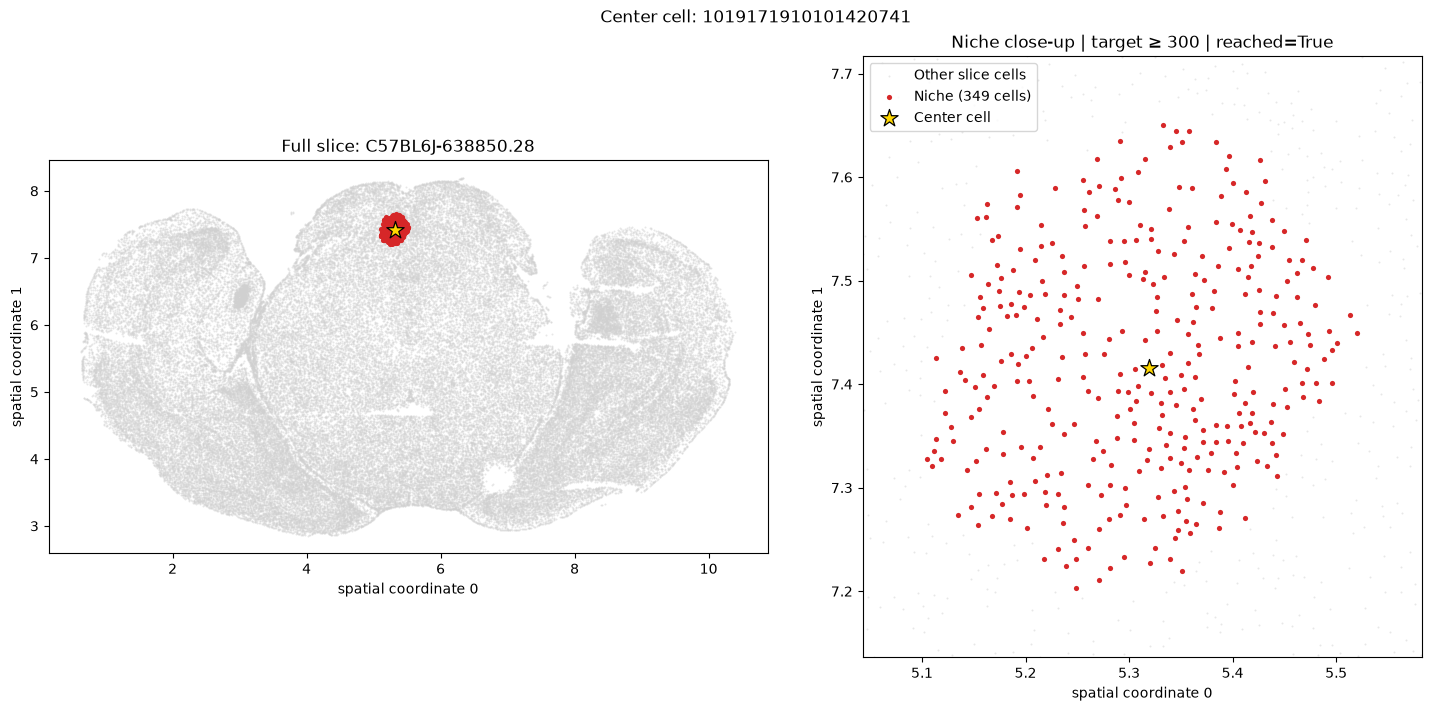

metrics: /home/sheryl/niche_query/NicheQueryBenchmark/experiment/query_niche_metrics/selected_query_niches/C57BL6J-638850.28_1019171910101420741/large/metrics.csv
composition_summary: /home/sheryl/niche_query/NicheQueryBenchmark/experiment/query_niche_metrics/selected_query_niches/C57BL6J-638850.28_1019171910101420741/large/composition_summary.csv
center_coordinates: /home/sheryl/niche_query/NicheQueryBenchmark/experiment/query_niche_metrics/selected_query_niches/C57BL6J-638850.28_1019171910101420741/large/center_coordinates.csv
members: /home/sheryl/niche_query/NicheQueryBenchmark/experiment/query_niche_metrics/selected_query_niches/C57BL6J-638850.28_1019171910101420741/large/members.csv
composition: /home/sheryl/niche_query/NicheQueryBenchmark/experiment/query_niche_metrics/selected_query_niches/C57BL6J-638850.28_1019171910101420741/large/composition.csv
source_composition_similarity: /home/sheryl/niche_query/NicheQueryBenchmark/experiment/query_niche_metrics/selected_query_niches/C5

In [8]:
# Full slice and a close-up of the same saved niche.
xy = coords[:, :2]
niche_xy = xy[member_indices]
fig, axes = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)
for ax in axes:
    ax.scatter(xy[:, 0], xy[:, 1], s=2, c='#d0d0d0', alpha=0.5,
               linewidths=0, rasterized=True, label='Other slice cells')
    ax.scatter(niche_xy[:, 0], niche_xy[:, 1], s=14, c='#d62728',
               linewidths=0, label=f'Niche ({len(member_names)} cells)', zorder=3)
    ax.scatter(*center_coords[:2], s=170, marker='*', c='#ffd700',
               edgecolors='black', linewidths=0.9, label='Center cell', zorder=4)
    ax.set(xlabel=f'{SPATIAL_KEY} coordinate 0', ylabel=f'{SPATIAL_KEY} coordinate 1')
    ax.set_aspect('equal', adjustable='box')
low, high = niche_xy.min(axis=0), niche_xy.max(axis=0)
padding = np.maximum((high - low) * 0.15, np.maximum(np.ptp(xy, axis=0) * 0.005, 1e-6))
axes[1].set_xlim(low[0] - padding[0], high[0] + padding[0])
axes[1].set_ylim(low[1] - padding[1], high[1] + padding[1])
axes[0].set_title(f'Full slice: {SLICE_NAME}')
axes[1].set_title(f'Niche close-up | target ≥ {TARGET_SIZE} | reached=True')
axes[1].legend(loc='best')
if INVERT_Y_AXIS:
    for ax in axes:
        ax.invert_yaxis()
fig.suptitle(f'Center cell: {CENTER_CELL_NAME}')
figure_path = output_dir / 'niche.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
output_paths['figure'] = figure_path
plt.show()
for name, path in output_paths.items():
    print(f'{name}: {path}')


In [10]:
# Build a presentation report with summary tables and embedded figures.
import base64
from html import escape
from IPython.display import FileLink


def report_table(title, table, *, expanded=False, description=None):
    # All rows/columns are included; large tables can be searched and scrolled.
    content = table.to_html(index=False, escape=True, border=0, na_rep='—',
                            max_rows=None, max_cols=None)
    definition = (f'<p><strong>Similarity rule:</strong> {escape(description)}</p>'
                  if description else '')
    return (f'<details {"open" if expanded else ""}><summary>{escape(title)} '
            f'<span>({len(table):,} rows)</span></summary>'
            + definition
            + '<label>Filter rows <input type="search" placeholder="Type to search this table" '
            'oninput="filterRows(this)"></label>'
            f'<div class="table-scroll">{content}</div></details>')


def report_image(title, image_path):
    encoded = base64.b64encode(image_path.read_bytes()).decode('ascii')
    return (f'<section><h2>{escape(title)}</h2>'
            f'<img alt="{escape(title, quote=True)}" src="data:image/png;base64,{encoded}"></section>')


metric_table = (summary_df.drop(columns=['niche_cell_names', 'parcellation_fractions'])
                .iloc[0].rename_axis('metric').reset_index(name='value'))
dominant_parcellation_fraction = max(query_composition.values())
metric_table.loc[len(metric_table)] = [
    'Dominant parcellation cell fraction (%)', f'{dominant_parcellation_fraction:.2%}'
]
composition_report_table = (composition_export_df.drop(columns=[
    'source_metrics_csv', 'source_h5ad'])
                           .iloc[0].rename_axis('metric').reset_index(name='value'))
report_tables = [
    ('Niche basic information', metric_table, True, None),
    ('Center coordinates', center_df, True, None),
    ('Parcellation composition', composition_df.loc[composition_df['fraction'] > 0], True, None),
    ('Source-slice composition', composition_report_table, True,
     'Every parcellation fraction must differ from the selected niche by strictly less than 0.05 (5 percentage points). Fractions are aligned by parcellation ID; missing IDs are treated as zero.'),
    ('Target-slice composition', slice_composition_table, True,
     'Every parcellation fraction must differ from the selected niche by strictly less than 0.25 (25 percentage points). Fractions are aligned by parcellation ID; missing IDs are treated as zero.'),
]
report_parts = [
    '<!doctype html><html lang="en"><head><meta charset="utf-8">'
    '<meta name="viewport" content="width=device-width, initial-scale=1">'
    '<title>Query niche report</title>',
    """<style>
    body {font: 16px/1.5 system-ui, sans-serif; color: #243247; background: #f5f7fa; margin: 0;}
    main {max-width: 1300px; margin: auto; padding: 28px;}
    header, section, details {background: white; border: 1px solid #dce2e9; border-radius: 10px; padding: 20px; margin-bottom: 20px;}
    h1 {margin: 0 0 12px;} h2 {font-size: 1.2rem;} p {overflow-wrap: anywhere;}
    summary {cursor: pointer; font-size: 1.1rem; font-weight: 600;}
    summary span {font-size: .9rem; color: #617086; font-weight: normal;}
    img {max-width: 100%; height: auto;} .table-scroll {max-height: 650px; overflow: auto; margin-top: 12px;}
    table {border-collapse: collapse; width: 100%; font-size: 14px;}
    th, td {text-align: left; padding: 8px 12px; border-bottom: 1px solid #e1e6ec; vertical-align: top;}
    th {position: sticky; top: 0; background: #edf2f8;} td {max-width: 600px; overflow-wrap: anywhere;}
    tr:nth-child(even) {background: #fafbfd;} label {display: block; margin-top: 15px;}
    input {padding: 7px; border: 1px solid #bbc7d5; border-radius: 5px;} a {color: #215a96;}
    @media print {.table-scroll {max-height: none; overflow: visible;} label {display: none;}}
    </style></head><body><main>""",
    f'<header><h1>Query niche report</h1><p><strong>Source slice:</strong> {escape(SLICE_NAME)}<br>'
    f'<strong>Center cell:</strong> {escape(CENTER_CELL_NAME)}<br>'
    f'<strong>Niche dimension:</strong> {escape(NICHE_DIMENSION)} (target ≥ {TARGET_SIZE} cells)</p>'
    f'<p><strong>Similar source-slice niches:</strong> {source_composition_summary["similar_niche_count"]:,} '
    f'({source_composition_summary["similar_niche_percent"]:.2f}%)<br>'
    f'<strong>Eligible source-slice niches:</strong> {source_composition_summary["candidate_niche_count"]:,}</p>'
    '<p>Source-slice similarity requires every parcellation fraction to differ by strictly less than '
    '0.05 (5 percentage points); target-slice similarity uses 0.25 (25 percentage points). '
    'Missing parcellation IDs have fraction zero. '
    'Source-slice counts include the selected niche and overlapping eligible exported neighborhoods. '
    'Percentages use all eligible exported niches in the respective slice and dimension as the denominator.</p></header>',
    report_image('Selected niche on the source slice', output_paths['figure']),
]
report_parts.extend(report_table(title, table, expanded=expanded, description=description)
                    for title, table, expanded, description in report_tables)
report_parts.append("""</main>
<script>
function filterRows(input) {
    const query = input.value.toLowerCase();
    input.closest('details').querySelectorAll('tbody tr').forEach(row => {
        row.hidden = !row.textContent.toLowerCase().includes(query);
    });
}
</script></body></html>""")
report_path = output_dir / 'report.html'
report_path.write_text('\n'.join(report_parts), encoding='utf-8')
output_paths['html_report'] = report_path
print(f'HTML report: {report_path}')
display(FileLink(str(report_path)))


HTML report: /home/sheryl/niche_query/NicheQueryBenchmark/experiment/query_niche_metrics/selected_query_niches/C57BL6J-638850.28_1019171910101420741/large/report.html


/home/sheryl/niche_query/NicheQueryBenchmark/experiment/query_niche_metrics/selected_query_niches/C57BL6J-638850.28_1019171910101420741/large/report.html